In [1]:
!pip install matplotlib seaborn



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Joining and Exploration

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
pd.set_option("display.max_columns",50)
pd.set_option("display.width",140)
sns.set_theme(style="darkgrid")

INTERIM_DIR = os.path.join("..","data","interim")

routes = pd.read_pickle(os.path.join(INTERIM_DIR,"routes_clean.pkl"))
vehicles = pd.read_pickle(os.path.join(INTERIM_DIR,"vehicles_clean.pkl"))
stops = pd.read_pickle(os.path.join(INTERIM_DIR,"stops_clean.pkl"))
validations = pd.read_pickle(os.path.join(INTERIM_DIR,"validations_clean.pkl"))


print({name: df.shape for name, df in[("routes", routes), ("vehicles",vehicles), ("stops",stops), ("validations",validations)]})


{'routes': (60, 6), 'vehicles': (180, 6), 'stops': (400, 5), 'validations': (67407, 21)}


### 1. Build a single fact table by joining validations -> routes -> vehicles -> stops.

### Validations is used as base, and we add LEFT JOIN

##### 2.Explain in markdown what join did you use and why
##### LEFT JOIN is the best to use in this case because the base table (validations) that is being counted, should never shrink because of an upstream table's problems. If we use for example INNER JOIN it may give us same results now, but if the guarantee is ever violated in future, it will give us different results,because it will drop every row that no longer matches. That is not the case with LEFT JOIN, because LEFT JOIN keeps the row and fills the  master table-columns with NaN and it is imposible to miss.

In [4]:
routes_to_join = routes.rename(columns={"district":"route_district"})
stops_to_join = stops.rename(columns={"district":"stop_district"})



master_table = validations.merge(routes_to_join, on="route_id", how= "left")
master_table = master_table.merge(vehicles, on="vehicle_id", how="left")
master_table = master_table.merge(stops_to_join, on="stop_id", how="left")

print("table shape :", master_table.shape)
master_table.head(3)

table shape : (67407, 35)


,validation_id,validation_ts,route_id,vehicle_id,stop_id,card_id,fare_type,fare_amount,passenger_count,transfer_flag,is_reversed,date,year,month,year_month,quarter,hour,day_of_week,is_weekend,time_period,revenue,route_name,mode,route_district,route_length_km,scheduled_trips_per_day,vehicle_type,capacity,year_manufactured,depot,vehicle_age_band,stop_name,stop_district,zone,has_shelter
0,VAL-0044034,2024-06-06 08:48:00,R058,V0086,S0131,CARD-000729,Adult,2.48,1.0,True,False,2024-06-06,2024,6,2024-06,2,8,Thursday,False,AM peak (07-09),2.48,Jennifer Locks Line,Bus,Parkview,12.6,49,Standard Bus,60,2005,North Depot,11-20,Caldwell Union Stop,Westend,Zone 3,True
1,VAL-0017450,2024-03-06 13:15:00,R043,V0177,S0251,CARD-020205,Adult,2.85,1.0,False,False,2024-03-06,2024,3,2024-03,1,13,Wednesday,False,Midday (10-15),2.85,Kelly Estate Line,Tram,Parkview,21.6,67,Tram,226,2009,East Depot,11-20,Lee Rapid Stop,Parkview,Zone 1,False
2,VAL-0053735,2024-06-14 18:35:27,R003,V0057,S0389,CARD-003251,Student,1.34,1.0,False,False,2024-06-14,2024,6,2024-06,2,18,Friday,False,PM Peak(16-18),1.34,Erica Plains Line,Metro,Southbank,4.3,203,Metro Set,596,<NA>,North Depot,Unknown,Moore Inlet Stop,Northgate,Zone 2,False


### 3. Assert row count matches - fail loudly on fan-out

In [5]:
expected_rows = len(validations)
actual_rows = len(master_table)

assert actual_rows == expected_rows, (
    f"Row count mismatch after join. Expected {expected_rows:,}, got {actual_rows:,} \n"
    f"This means a master table (routes/vehicles/stops) has a duplicate ID causing fan-out, \n"
    f"or validations lsot rows some other way. Investigate before trusting anything downstream."
)
print(f"Ok-fact table row count({actual_rows:,}) matches cleaned validations ({expected_rows:,})")

#Null check

null_check = master_table[["route_name", "vehicle_type", "stop_name"]].isna().sum()
print("\nnulls introduced by the join:")
print(null_check)

Ok-fact table row count(67,407) matches cleaned validations (67,407)

nulls introduced by the join:
route_name      0
vehicle_type    0
stop_name       0
dtype: int64


### 4.Derive **load_factor = passanger_count / capacity** at vehicle-trip level where meaningful

In [6]:
vehicle_trip_load_factor = (
    master_table.groupby(["vehicle_id", "vehicle_type", "date", "hour"], as_index=False)
    .agg(
        total_passengers=("passenger_count", "sum"), 
        capacity=("capacity", "first") 
    )
)

vehicle_trip_load_factor["load_factor"] = (
    vehicle_trip_load_factor["total_passengers"] / vehicle_trip_load_factor["capacity"]
)

print(f"{len(vehicle_trip_load_factor):,} vehicle-trip groups calculated.")
vehicle_trip_load_factor.sort_values("load_factor", ascending=False).head()


61,867 vehicle-trip groups calculated.


,vehicle_id,vehicle_type,date,hour,total_passengers,capacity,load_factor
46303,V0135,Standard Bus,2024-02-25,16,6.0,61,0.098361
13548,V0039,Standard Bus,2024-03-13,16,6.0,66,0.090909
53969,V0157,Standard Bus,2024-03-18,15,5.0,62,0.080645
44204,V0129,Standard Bus,2024-01-18,19,5.0,64,0.078125
43303,V0126,Standard Bus,2024-05-22,20,5.0,71,0.070423


## 5.Exploratory charts  
#### Hourly ridership curve

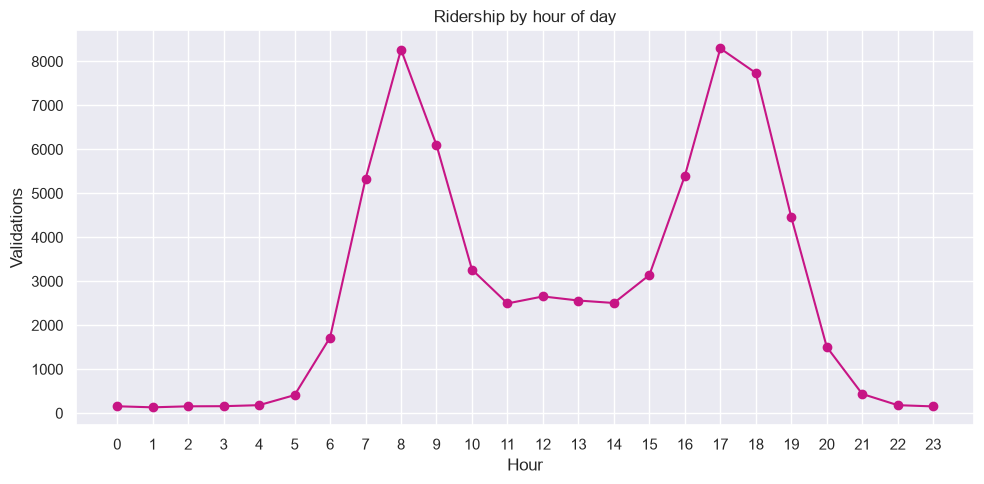

In [7]:
hourly = master_table.groupby("hour").size()

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(hourly.index, hourly.values, marker="o", color="#C71585" )
ax.set_title("Ridership by hour of day")
ax.set_xlabel("Hour")
ax.set_ylabel("Validations")
ax.set_xticks(range(0,24))
plt.tight_layout()
plt.show()

### Weekday vs. weekend comparison

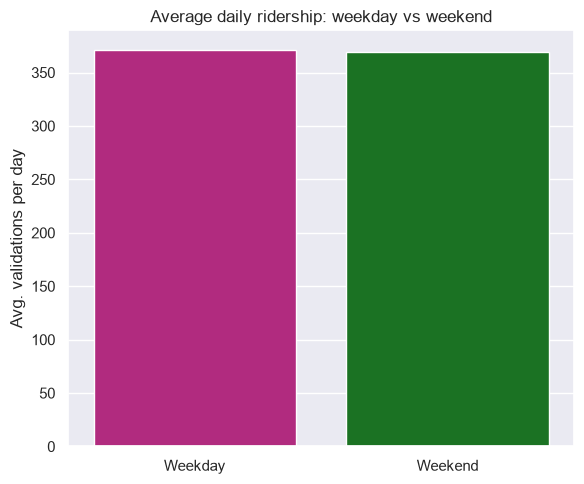

In [8]:
daily_counts = master_table.groupby(["date", "is_weekend"]).size().reset_index(name="validations")
avg_by_day_counts = daily_counts.groupby("is_weekend")["validations"].mean()
avg_by_day_counts.index = avg_by_day_counts.index.map({False: "Weekday", True: "Weekend"})

fig, ax = plt.subplots(figsize=(6,5))
sns.barplot(x=avg_by_day_counts.index, y=avg_by_day_counts.values, hue=avg_by_day_counts.index,
            palette=["#C71585","#0C8117"], legend=False, ax=ax)
ax.set_title("Average daily ridership: weekday vs weekend")
ax.set_ylabel("Avg. validations per day")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## Ridership by mode

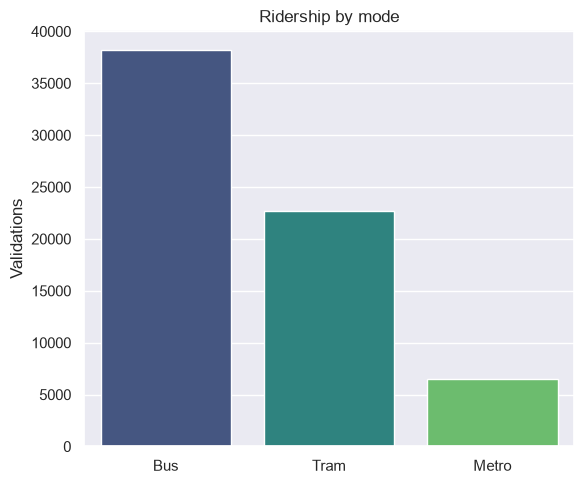

In [9]:
mode_counts = master_table["mode"].value_counts()

fig,ax = plt.subplots(figsize=(6,5))
sns.barplot(x=mode_counts.index, y=mode_counts.values, hue=mode_counts.index,
            palette="viridis", legend=False, ax=ax)
ax.set_title("Ridership by mode")
ax.set_ylabel("Validations")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## Fare type mix 

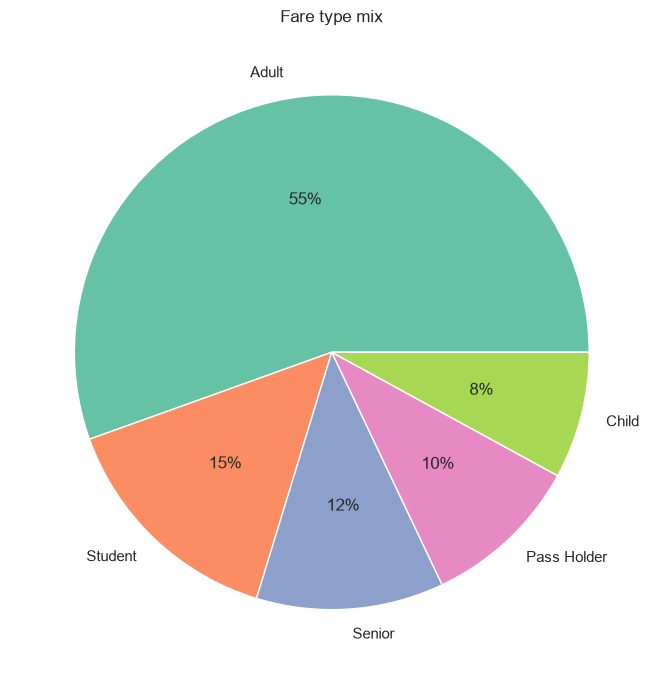

In [10]:
fare_counts = master_table["fare_type"].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(fare_counts.values, labels=fare_counts.index, autopct="%1.0f%%",
       colors=sns.color_palette("Set2", len(fare_counts)))
ax.set_title("Fare type mix")
plt.tight_layout()
plt.show()

## Top routes

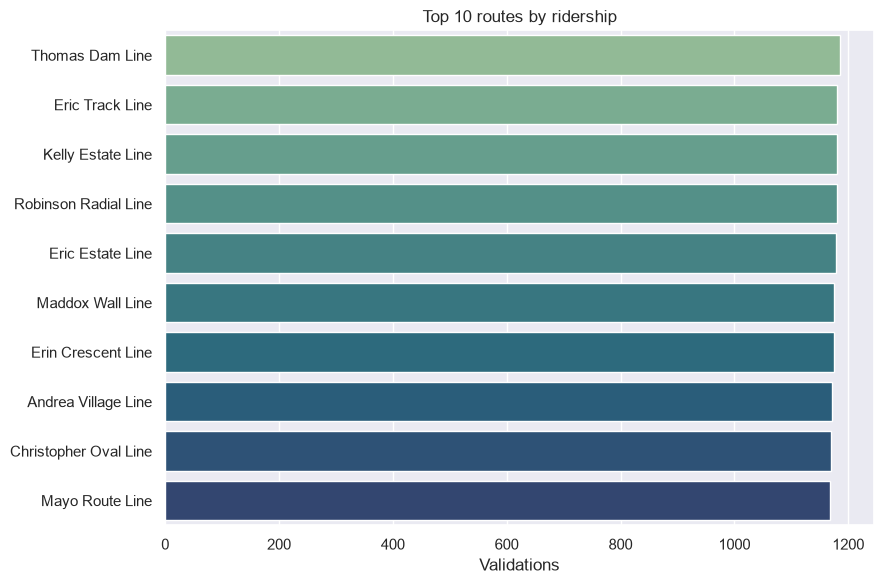

In [11]:
top_routes = master_table.groupby("route_name").size().sort_values(ascending=False).head(10)


fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_routes.values, y=top_routes.index, hue=top_routes.index,
            palette="crest", legend=False, ax=ax)
ax.set_title("Top 10 routes by ridership")
ax.set_xlabel("Validations")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## District distribution

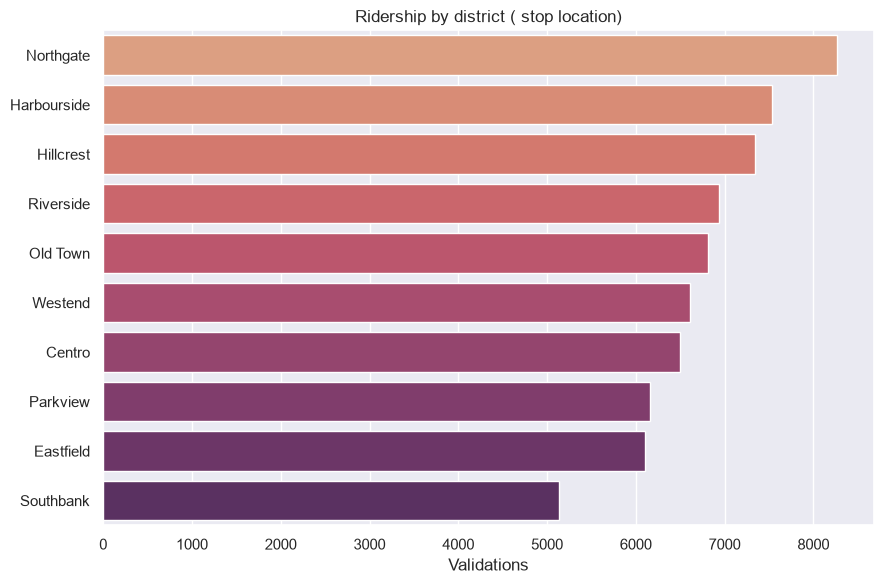

In [12]:
district_counts = master_table["stop_district"].value_counts().sort_values(ascending=False)

fig,ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=district_counts.values, y=district_counts.index, hue=district_counts.index,
            palette="flare",legend=False, ax=ax)
ax.set_title("Ridership by district ( stop location)")
ax.set_xlabel("Validations")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [13]:
output_path = os.path.join(INTERIM_DIR, "fact_validations.parquet") 

try:
    master_table.to_parquet(output_path, index=False)
    print(f"saved {output_path} ({len(master_table):,} rows)") 

except ImportError: 
    fallback_path = output_path.replace(".parquet", ".pkl") 
    master_table.to_pickle(fallback_path) 
    print(f"pyarrow/fastparquet not installed in this environment — saved fallback instead: {fallback_path}") 
    print("Run `pip install pyarrow` and re-run this cell to get the spec-compliant .parquet file.")


saved ..\data\interim\fact_validations.parquet (67,407 rows)


In [14]:
pip install pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
print(type(master_table))

<class 'pandas.DataFrame'>


In [16]:
print("VALUE:", master_table)

VALUE:       validation_id       validation_ts route_id vehicle_id stop_id      card_id    fare_type  fare_amount  passenger_count  \
0       VAL-0044034 2024-06-06 08:48:00     R058      V0086   S0131  CARD-000729        Adult         2.48              1.0   
1       VAL-0017450 2024-03-06 13:15:00     R043      V0177   S0251  CARD-020205        Adult         2.85              1.0   
2       VAL-0053735 2024-06-14 18:35:27     R003      V0057   S0389  CARD-003251      Student         1.34              1.0   
3       VAL-0052211 2024-02-16 18:30:59     R013      V0068   S0350  CARD-010226        Adult         2.47              1.0   
4       VAL-0011169 2024-03-03 08:41:00     R031      V0018   S0320  SINGLE_RIDE  Pass Holder         0.13              1.0   
...             ...                 ...      ...        ...     ...          ...          ...          ...              ...   
67402   VAL-0006266 2024-03-25 14:45:38     R002      V0132   S0265  CARD-016268        Adult         2.